In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm  = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [15]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages

class STATE(TypedDict):
    messages:Annotated[list ,add_messages]


def Chatbot(state:STATE):
    return {"messages": llm.invoke(state["messages"])}

In [16]:
graph_builder = StateGraph(STATE)
graph_builder.add_node("LLmChatbot" , Chatbot)
graph_builder.add_edge(START , 'LLmChatbot')
graph_builder.add_edge('LLmChatbot' , END)

graph = graph_builder.compile()

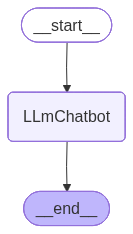

In [17]:
from IPython.display import display , Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
response =graph.invoke({"messages":"hi how are you"})
response

{'messages': [HumanMessage(content='hi how are you', additional_kwargs={}, response_metadata={}, id='d40f30d9-5adf-408b-bf6a-92c1c2af22eb'),
  AIMessage(content=[{'type': 'text', 'text': "I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHnMz3hcfMEhq+YGb3+vwAHUf5XBmzH3Wq6eibrBLhTAQ6X4uWTRx8Twcb/ONI'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9c6f-bb91-7010-87b4-f8d99a03e182-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 26, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}})]}

In [24]:
print(response['messages'][-1].text)

I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?
